# German Credit SHAP-based Scorecard with XGBoost (scorecardpl)

This notebook builds a SHAP-derived scorecard using an XGBoost classifier trained on WOE features from the German Credit dataset.

Steps:
- Load dataset and map target to 0/1
- Train/valid split + variable filtering
- WOE/IV binning (numeric + categorical)
- Train XGBoost on WOE features
- Build scorecard points via SHAP contributions
- Evaluate AUC/KS, compute PSI, and export a simple report


Note: Compatible with SHAP 0.48+ (handles new values shape and TreeExplainer fallback).


In [3]:
%matplotlib inline
# If needed, uncomment to install deps in this environment
# !pip -q install xgboost shap

import os
import numpy as np
import pandas as pd
import polars as pl
import xgboost as xgb
import shap

from scorecardpl import (
    split_df, var_filter, woebin, woebin_ply,
    scorecard_ply, perf_eva, iv_summary, psi,
    bins_export_json, bins_import_json, write_method_report,
    scorecard_shap, SHAPScorecardModel, woebin_plot,
)


## Load German Credit data

We fetch the Statlog German Credit dataset from UCI. The label maps to 0/1 as: 1=good (0), 2=bad (1).

In [4]:
uci_url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data'
cols = [
    'Status', 'Duration', 'CreditHistory', 'Purpose', 'CreditAmount',
    'Savings', 'Employment', 'InstallmentRate', 'PersonalStatusSex', 'OtherDebtors',
    'ResidenceSince', 'Property', 'Age', 'OtherInstallmentPlans', 'Housing',
    'ExistingCredits', 'Job', 'Liables', 'Telephone', 'ForeignWorker', 'class'
]
df_pd = pd.read_csv(uci_url, sep=' ', header=None, names=cols)
# Map target: 1 (good) -> 0, 2 (bad) -> 1
df_pd['y'] = (df_pd['class'] == 2).astype(int)
df_pd = df_pd.drop(columns=['class'])
df_pl = pl.from_pandas(df_pd)
df_pl.head()


Status,Duration,CreditHistory,Purpose,CreditAmount,Savings,Employment,InstallmentRate,PersonalStatusSex,OtherDebtors,ResidenceSince,Property,Age,OtherInstallmentPlans,Housing,ExistingCredits,Job,Liables,Telephone,ForeignWorker,y
str,i64,str,str,i64,str,str,i64,str,str,i64,str,i64,str,str,i64,str,i64,str,str,i64
"""A11""",6,"""A34""","""A43""",1169,"""A65""","""A75""",4,"""A93""","""A101""",4,"""A121""",67,"""A143""","""A152""",2,"""A173""",1,"""A192""","""A201""",0
"""A12""",48,"""A32""","""A43""",5951,"""A61""","""A73""",2,"""A92""","""A101""",2,"""A121""",22,"""A143""","""A152""",1,"""A173""",1,"""A191""","""A201""",1
"""A14""",12,"""A34""","""A46""",2096,"""A61""","""A74""",2,"""A93""","""A101""",3,"""A121""",49,"""A143""","""A152""",1,"""A172""",2,"""A191""","""A201""",0
"""A11""",42,"""A32""","""A42""",7882,"""A61""","""A74""",2,"""A93""","""A103""",4,"""A122""",45,"""A143""","""A153""",1,"""A173""",2,"""A191""","""A201""",0
"""A11""",24,"""A33""","""A40""",4870,"""A61""","""A73""",3,"""A93""","""A101""",4,"""A124""",53,"""A143""","""A153""",2,"""A173""",2,"""A191""","""A201""",1


## Split and filter

In [6]:
y = 'y'
xs = [c for c in df_pl.columns if c != y]
train, valid = split_df(df_pl, y=y, test_size=0.3, random_state=42)
train = var_filter(train, y=y, x=xs)
train.shape, valid.shape


((700, 21), (300, 21))

## Binning: chi2 (numeric) + supervised category merging

Use monotonic WOE = 'auto'.

In [7]:
bins = woebin(
    train, y=y, x=[c for c in train.columns if c != y],
    bins=6, method='chi2', chi2_params={'init_bins': 60},
    monotonic='auto', cat_max_bins=5,
)
ivsum = iv_summary(bins)
ivsum


variable,iv,nbin
str,f64,i64
"""Status""",0.809315,4
"""CreditAmount""",0.58496,3
"""CreditHistory""",0.326533,5
"""Savings""",0.232083,5
"""Duration""",0.221583,3
…,…,…
"""ResidenceSince""",0.013592,3
"""Telephone""",0.012284,2
"""ExistingCredits""",0.00422,2


## Train XGBoost on WOE and derive scorecard via SHAP

In [8]:
est = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
)
sc_shap = scorecard_shap(
    bins=bins, y=y, data=train, estimator=est,
    shap_sample_n=2000, pdo=20.0, base_score=600.0, odds=50.0
)
type(sc_shap)


scorecardpl.shapcard.SHAPScorecardModel

## Evaluate on validation set

In [9]:
# estimator probabilities on WOE features
proba = sc_shap.predict_proba(valid, bins)
perf = perf_eva(valid[y], proba, plot='both', save_prefix='plots/german_credit_xgb_shap')
perf


{'auc': 0.7551322751322753, 'ks': 0.4126984126984127}

### Score application

In [10]:
points = sc_shap.predict_points(valid, bins)
points.head(10)


score
f64
737.84076
737.84076
737.84076
737.84076
737.84076
737.84076
737.84076
737.84076
737.84076


In [14]:
bins

{'Status': shape: (4, 11)
 ┌──────────┬─────┬───────┬─────┬───┬───────────┬──────────┬───────────┬─────┐
 │ variable ┆ bin ┆ count ┆ bad ┆ … ┆ woe       ┆ iv       ┆ levels    ┆ ord │
 │ ---      ┆ --- ┆ ---   ┆ --- ┆   ┆ ---       ┆ ---      ┆ ---       ┆ --- │
 │ str      ┆ str ┆ u32   ┆ i64 ┆   ┆ f64       ┆ f64      ┆ list[str] ┆ i64 │
 ╞══════════╪═════╪═══════╪═════╪═══╪═══════════╪══════════╪═══════════╪═════╡
 │ Status   ┆ A11 ┆ 200   ┆ 103 ┆ … ┆ -0.907316 ┆ 0.265405 ┆ ["A11"]   ┆ 0   │
 │ Status   ┆ A12 ┆ 179   ┆ 69  ┆ … ┆ -0.380924 ┆ 0.039647 ┆ ["A12"]   ┆ 1   │
 │ Status   ┆ A14 ┆ 275   ┆ 28  ┆ … ┆ 1.329886  ┆ 0.493053 ┆ ["A14"]   ┆ 2   │
 │ Status   ┆ A13 ┆ 46    ┆ 10  ┆ … ┆ 0.433636  ┆ 0.01121  ┆ ["A13"]   ┆ 3   │
 └──────────┴─────┴───────┴─────┴───┴───────────┴──────────┴───────────┴─────┘,
 'Duration': shape: (3, 12)
 ┌──────────┬─────────────┬─────┬───────┬───┬──────────┬───────────┬───────────┬──────────┐
 │ variable ┆ bin         ┆ ord ┆ lower ┆ … ┆ bad_rate ┆ good_r

## PSI between train and validation

In [15]:
psi_df = psi(train, valid, bins)
psi_df


variable,psi
str,f64
"""Purpose""",0.04939
"""CreditHistory""",0.041662
"""PersonalStatusSex""",0.028376
"""ResidenceSince""",0.020524
"""ForeignWorker""",0.019915
…,…
"""ExistingCredits""",0.002143
"""Housing""",0.001659
"""InstallmentRate""",0.001431


## Optional: SHAP summary plot for WOE features

We recompute SHAP values on validation WOE features to visualize feature importance.

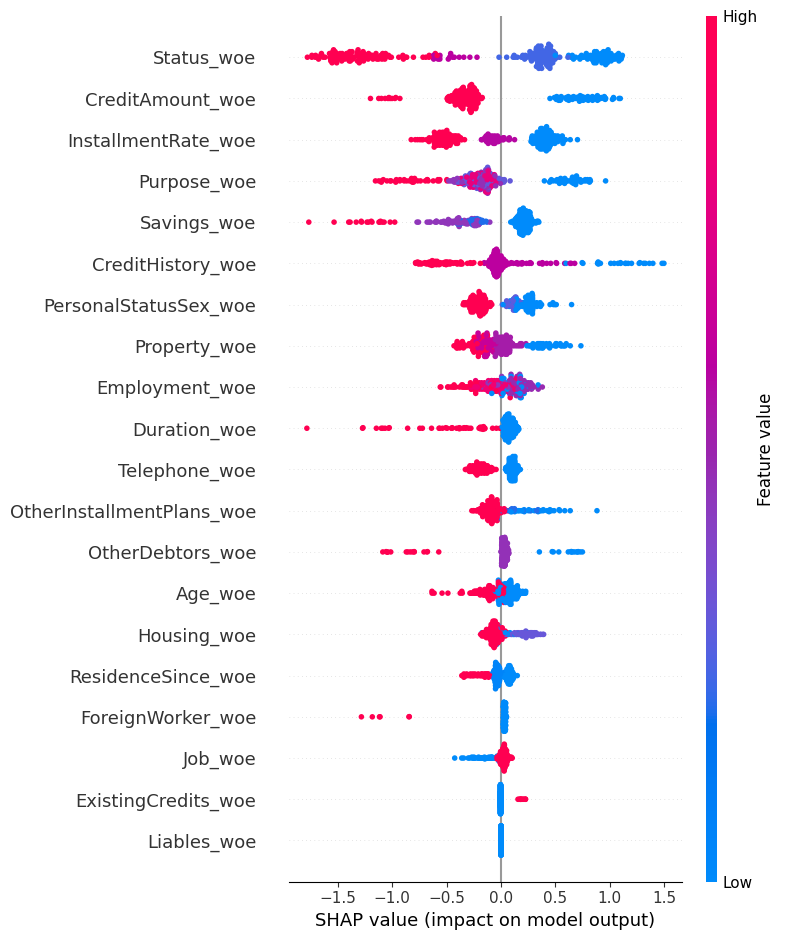

In [13]:
valid_w = woebin_ply(valid, bins, keep_bins=False)
feat_cols = [c for c in valid_w.columns if c.endswith('_woe')]
Xv = valid_w.select(feat_cols).to_numpy()
expl = shap.TreeExplainer(sc_shap.estimator, feature_names=feat_cols, model_output='raw')
sv = expl(Xv)
shap.summary_plot(sv, features=Xv, feature_names=feat_cols, show=True)


## Export bins and write a simple performance report

In [ ]:
os.makedirs('reports', exist_ok=True)
bins_export_json(bins, 'reports/german_credit_bins_shap_xgb.json')
rows = [{
    'method': 'XGB_WOE_SHAP',
    'auc': float(perf['auc']),
    'ks': float(perf['ks']),
}]
write_method_report(rows, out_prefix='reports/german_credit_xgb_shap_perf')
